In [50]:
from matplotlib import pyplot as plt
from utils import DataProcessor
import json
import warnings
warnings.filterwarnings('ignore')

In [51]:
import joblib
with open('../../../Models/gam.pkl', 'rb') as f:
    model = joblib.load(f)
with open('../cat_top_features.json', 'r') as f:
    cat_top_features = json.load(f)
data = DataProcessor("../../hyper_wheat_ds_ch_norm_prep_mode=dai.csv").split_data()


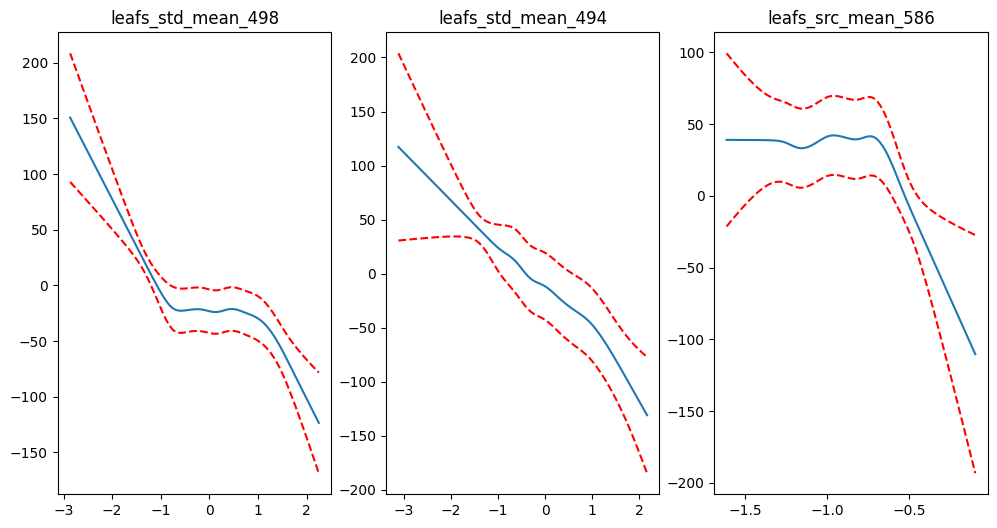

In [52]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
titles = cat_top_features[:3]

for i, ax in enumerate(axs):
    XX = model.generate_X_grid(term=i)
    pdep, confi = model.partial_dependence(term=i, width=0.95)

    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi, c="r", ls="--")
    ax.set_title(titles[i])

plt.show()

In [53]:
print(model.summary())

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     79.9307
Link Function:                        LogitLink Log Likelihood:                                   -94.4009
Number of Samples:                         2306 AIC:                                              348.6632
                                                AICc:                                             354.6259
                                                UBRE:                                               2.1789
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9409
Feature Function                  Lam